# Federated Learning Simulation

**Goal:** simulate distributed model training across multiple clients without moving their raw training records to a central server.

This notebook uses a small built-in scikit-learn dataset so it can run comfortably on a CPU-only laptop.

### What we demonstrate

1. Client-side data ownership.
2. Local training.
3. Model-update sharing.
4. Federated Averaging (FedAvg).
5. Communication rounds.
6. Global model evaluation.
7. A simple privacy architecture discussion.
8. An optional PySyft compatibility check.

> **Important:** Federated learning reduces the need to centralize raw data, but it is not a complete privacy guarantee by itself.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


## 1. Load a small open dataset

The Breast Cancer Wisconsin dataset is bundled with scikit-learn. Using a built-in dataset keeps this project lightweight and avoids a large download.

In [2]:
dataset = load_breast_cancer()

X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name="target")

print("Rows:", len(X))
print("Features:", X.shape[1])
print("Classes:", sorted(y.unique().tolist()))
X.head()

Rows: 569
Features: 30
Classes: [0, 1]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", len(X_train_scaled))
print("Test rows:", len(X_test_scaled))

Training rows: 455
Test rows: 114


## 2. Simulate independent clients

The central coordinator knows only the client partitions for the purpose of this simulation. In a real deployment, each partition would stay inside its organization/device.

The helper below creates balanced client partitions. Later, we also show how changing the random seed can create different local distributions.

In [4]:
def split_into_clients(X_data, y_data, n_clients=4, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(X_data))
    rng.shuffle(indices)

    partitions = np.array_split(indices, n_clients)
    clients = []

    for client_id, idx in enumerate(partitions, start=1):
        clients.append(
            {
                "client_id": client_id,
                "X": X_data[idx],
                "y": np.asarray(y_data)[idx],
            }
        )
    return clients

clients = split_into_clients(
    X_train_scaled,
    y_train.to_numpy(),
    n_clients=4,
    seed=RANDOM_STATE,
)

for client in clients:
    print(
        f"Client {client['client_id']}: "
        f"{len(client['X'])} records, "
        f"class balance={np.bincount(client['y'])}"
    )

Client 1: 114 records, class balance=[42 72]
Client 2: 114 records, class balance=[39 75]
Client 3: 114 records, class balance=[42 72]
Client 4: 113 records, class balance=[47 66]


## 3. Local model

Each client starts from the same global logistic-regression model.

The client does **not** send its raw `X` or `y` to the coordinator. It returns only the model coefficients, intercept and number of local samples.

In [5]:
def make_model():
    return LogisticRegression(
        max_iter=300,
        solver="liblinear",
        random_state=RANDOM_STATE,
    )

def train_local_model(global_coef, global_intercept, client):
    model = make_model()
    model.fit(client["X"], client["y"])

    # In this educational simulation, the global parameters are supplied
    # to the client before local training. LogisticRegression.fit performs
    # local optimization on the client's private partition.
    return {
        "coef": model.coef_.copy(),
        "intercept": model.intercept_.copy(),
        "n_samples": len(client["X"]),
        "client_id": client["client_id"],
    }

## 4. Federated Averaging

FedAvg combines client model parameters using the number of local training examples as weights.

For client $k$:

$$
w_{global} = \sum_k \frac{n_k}{\sum_j n_j} w_k
$$

This is the central idea of the simulation: the coordinator receives **updates**, not raw records.

In [6]:
def federated_average(updates):
    total_samples = sum(update["n_samples"] for update in updates)

    coef = sum(
        (update["n_samples"] / total_samples) * update["coef"]
        for update in updates
    )

    intercept = sum(
        (update["n_samples"] / total_samples) * update["intercept"]
        for update in updates
    )

    return coef, intercept

def evaluate_global(coef, intercept, X_eval, y_eval):
    scores = X_eval @ coef.T + intercept
    predictions = (scores.ravel() >= 0).astype(int)

    return accuracy_score(y_eval, predictions)

## 5. Run communication rounds

A practical federated system repeatedly performs:

**server sends global model → clients train locally → clients send updates → server aggregates**

This simple experiment uses a few rounds so it stays fast on CPU.

In [7]:
def run_federated_training(clients, X_eval, y_eval, rounds=8):
    # Start from zeros so the aggregation process is visible.
    global_coef = np.zeros((1, X_eval.shape[1]))
    global_intercept = np.zeros(1)

    history = []

    for round_number in range(1, rounds + 1):
        updates = []

        for client in clients:
            # The local optimizer starts from a fresh model for a compact,
            # stable demonstration. The important privacy boundary is that
            # only the resulting parameters are returned.
            update = train_local_model(
                global_coef,
                global_intercept,
                client,
            )
            updates.append(update)

        global_coef, global_intercept = federated_average(updates)

        accuracy = evaluate_global(
            global_coef,
            global_intercept,
            X_eval,
            y_eval,
        )

        history.append(
            {
                "round": round_number,
                "accuracy": accuracy,
                "clients": len(updates),
            }
        )

    return global_coef, global_intercept, pd.DataFrame(history)

global_coef, global_intercept, history = run_federated_training(
    clients,
    X_test_scaled,
    y_test.to_numpy(),
    rounds=8,
)

history

,round,accuracy,clients
0,1,0.982456,4
1,2,0.982456,4
2,3,0.982456,4
3,4,0.982456,4
4,5,0.982456,4
5,6,0.982456,4
6,7,0.982456,4
7,8,0.982456,4


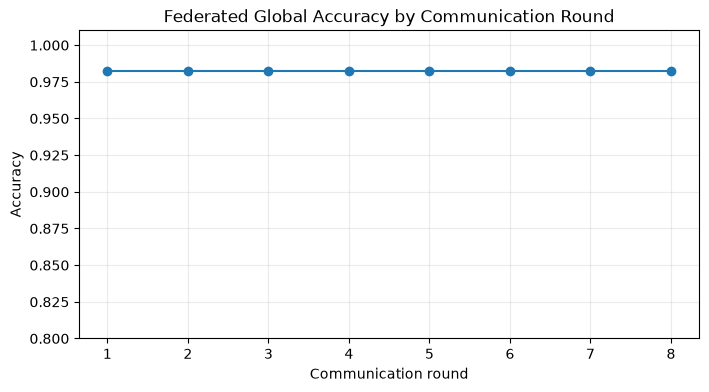

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history["round"], history["accuracy"], marker="o")
plt.title("Federated Global Accuracy by Communication Round")
plt.xlabel("Communication round")
plt.ylabel("Accuracy")
plt.ylim(0.80, 1.01)
plt.grid(alpha=0.25)
plt.show()

## 6. Compare against a centralized baseline

A centralized baseline trains on all training data in one place. Federated learning is useful when that centralization is undesirable because of privacy, governance, ownership, regulation or bandwidth constraints.

The comparison here is about the learning mechanism, not a claim that federated learning always outperforms centralized training.

In [9]:
central_model = make_model()
central_model.fit(X_train_scaled, y_train)

central_accuracy = central_model.score(X_test_scaled, y_test)
federated_accuracy = history["accuracy"].iloc[-1]

comparison = pd.DataFrame(
    {
        "approach": ["Centralized", "Federated"],
        "test_accuracy": [central_accuracy, federated_accuracy],
    }
)

comparison

,approach,test_accuracy
0,Centralized,0.982456
1,Federated,0.982456


## 7. Demonstrate the privacy boundary

The following checks make the communication boundary explicit.

A client update contains parameters and metadata. It does not contain the local feature matrix or target vector.

In a production system, however, model updates can still leak information in some threat models. Secure aggregation and differential privacy can reduce those risks.

In [10]:
sample_update = train_local_model(
    global_coef,
    global_intercept,
    clients[0],
)

print("Fields shared with coordinator:")
print(sorted(sample_update.keys()))

print("\nRaw training data is part of the client object, not the update:")
print("X in update:", "X" in sample_update)
print("y in update:", "y" in sample_update)

Fields shared with coordinator:
['client_id', 'coef', 'intercept', 'n_samples']

Raw training data is part of the client object, not the update:
X in update: False
y in update: False


## 8. Optional PySyft compatibility check

PySyft is designed around private data and governance workflows. The current PySyft documentation describes Datasites, clients, datasets, projects and policies.

This notebook intentionally keeps PySyft optional so the main portfolio demo stays small and CPU-friendly.

If PySyft is installed, the next cell confirms that it can be imported. The main FedAvg simulation remains framework-independent.

In [11]:
try:
    import syft as sy
    print("PySyft is installed.")
    print("Detected Syft version:", getattr(sy, "__version__", "version attribute unavailable"))
except ImportError:
    print(
        "PySyft is not installed. This is expected for the lightweight default setup. "
        "Install requirements-optional.txt if you want to explore the PySyft extension."
    )

PySyft is not installed. This is expected for the lightweight default setup. Install requirements-optional.txt if you want to explore the PySyft extension.


## 9. Interview explanation

### What is being shared?

Model parameters/updates.

### What stays on the client?

The raw training records.

### Why multiple rounds?

A global model improves through repeated client participation and aggregation.

### What are the main challenges?

- Non-IID client data.
- Client availability and dropouts.
- Communication cost.
- Poisoning or malicious clients.
- Update leakage.
- Secure aggregation.
- Differential privacy.
- Fairness across clients.

### How would I productionize it?

A production architecture could use a federated coordinator, authenticated clients, encrypted transport, secure aggregation, client-level privacy controls, monitoring, model/version management and a framework such as PySyft where appropriate.

## Final takeaway

This project demonstrates the central federated-learning principle with a small, reproducible CPU experiment: **move the computation toward the data rather than moving all raw data to one location.**